### **Diffusion Model**

### **Summary of the Diffusion Model**

This notebook employed a simplified 1D diffusion model designed to learn and generate samples from a target data distribution, which was a mixture of two Gaussian distributions.

### **Key Steps**

**1. Getting the Target Data Distribution:**

The model operates on a 1D dataset drawn from a `MixtureSameFamily` distribution, comprising two distinct Gaussian components. This represents the 'true' or 'target' distribution we aim to learn.

**2. Forward Diffusion Process:**

Noise is progressively added to the data over `TIME_STEPS` (250 steps in this case). This process, parameterized by `betas` and `alphas`, gradually transforms the complex data distribution into a simpler, more Gaussian-like noise distribution.

Visualizations show how the initial bimodal distribution diffuses into a broader, single-peaked distribution as `t` increases upto 249 time step.

**3. Noise Predictor Network (`g`):**

 At the core of the model is a simple feed-forward neural network, `NoisePredictor`, which takes a noisy data point (`xt`) and the current time step (`t`) as input. Its task is to predict the noise (`eps`) that was added to the original data point (`x0`) to reach `xt`.

**4. Training:**


The `NoisePredictor` is trained for `N_EPOCHS` (5000) using a Mean Squared Error (MSE) loss function. The training objective is to minimize the difference between the predicted noise and the actual noise sampled during the forward process.


Training involves iterating through mini-batches, adding noise, and then optimizing the network to predict that noise.


Training and validation loss curves were plotted, indicating that the `NoisePredictor` itself struggles to achieve low, stable loss, suggesting it might not be perfectly predicting noise at each step.

**5. Reverse Diffusion (Sampling):**

After training, the `NoisePredictor` is used to reverse the diffusion process. Starting from pure noise, the model iteratively denoises the samples over `TIME_STEPS` to generate new data points that resemble the original data distribution.


Visualizations of the reverse diffusion trajectory show the transformation from a Gaussian-like noise back to the bimodal target distribution.

**6. Evaluation of Generated Samples:**


The quality of the generated samples is quantified by comparing their Probability Density Function (PDF) with the true data's PDF using two metrics:

 **Mean Squared Error (MSE):** A low MSE (e.g., 0.000272) indicates a close resemblance between the generated and true distributions.

**Kullback-Leibler (KL) Divergence:** A low KL divergence (e.g., 0.030607) further confirms that the generated distribution is a good approximation of the true distribution in an information-theoretic sense.

**7. Last Comments**


  0%|          | 0/5000 [00:00<?, ?it/s]

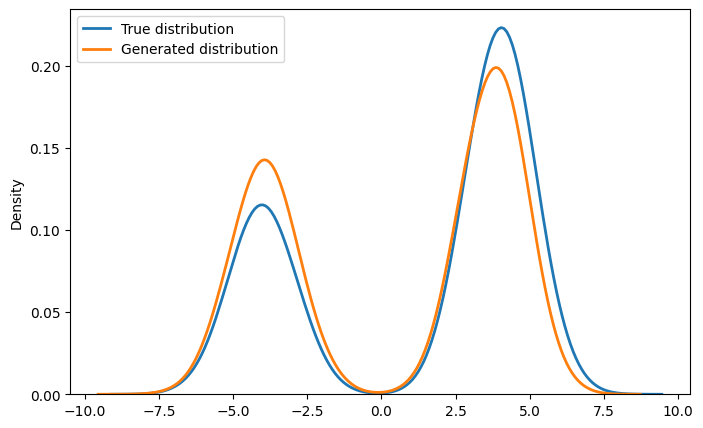

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns
from tqdm.auto import tqdm


# DATA


data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(
        torch.tensor([-4., 4.]),
        torch.tensor([1., 1.])
    )
)

dataset = data_distribution.sample((10000,))
dataset_validation = data_distribution.sample((1000,))


# HYPERPARAMETERS


TIME_STEPS = 250
BETA = 0.01

N_EPOCHS = 5000
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

betas = torch.full((TIME_STEPS,), BETA)

alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


# NETWORK


class NoisePredictor(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, 128),
            torch.nn.ReLU(),

            torch.nn.Linear(128, 128),
            torch.nn.ReLU(),

            torch.nn.Linear(128, 128),
            torch.nn.ReLU(),

            torch.nn.Linear(128, 1)
        )

    def forward(self, x, t):

        t = t.float() / TIME_STEPS

        inp = torch.stack([x, t], dim=1)

        return self.net(inp).squeeze()

g = NoisePredictor()

optimizer = torch.optim.Adam(
    g.parameters(),
    lr=LEARNING_RATE
)

loss_fn = torch.nn.MSELoss()


# TRAINING


epochs = tqdm(range(N_EPOCHS))

train_losses = []
val_losses = []

for e in epochs:

    g.train()

    indices = torch.randperm(len(dataset))
    shuffled_dataset = dataset[indices]

    current_epoch_train_losses = []

    for i in range(
        0,
        len(shuffled_dataset) - BATCH_SIZE,
        BATCH_SIZE
    ):

        x0 = shuffled_dataset[i:i+BATCH_SIZE]

        t = torch.randint(
            0,
            TIME_STEPS,
            (BATCH_SIZE,)
        )

        eps = torch.randn_like(x0)

        alpha_bar_t = alpha_bars[t]

        xt = (
            torch.sqrt(alpha_bar_t) * x0
            +
            torch.sqrt(1 - alpha_bar_t) * eps
        )

        pred_eps = g(xt, t)

        loss = loss_fn(pred_eps, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        current_epoch_train_losses.append(loss.item())

    train_losses.append(np.mean(current_epoch_train_losses))

    # ---------------- Validation ----------------

    g.eval()

    with torch.no_grad():

        x0 = dataset_validation

        t = torch.randint(
            0,
            TIME_STEPS,
            (len(x0),)
        )

        eps = torch.randn_like(x0)

        alpha_bar_t = alpha_bars[t]

        xt = (
            torch.sqrt(alpha_bar_t) * x0
            +
            torch.sqrt(1 - alpha_bar_t) * eps
        )

        pred_eps = g(xt, t)

        val_loss = loss_fn(pred_eps, eps)
        val_losses.append(val_loss.item())

    epochs.set_description(
        f"train={train_losses[-1]:.4f} val={val_losses[-1]:.4f}"
    )

# REVERSE DIFFUSION


def sample_reverse(model, count):

    model.eval()

    x = torch.randn(count)

    trajectory = [x.clone()]

    with torch.no_grad():

        for t in reversed(range(TIME_STEPS)):

            t_batch = torch.full(
                (count,),
                t,
                dtype=torch.long
            )

            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            eps_theta = model(x, t_batch)

            mean = (
                1.0 / torch.sqrt(alpha_t)
            ) * (
                x
                -
                beta_t
                / torch.sqrt(1 - alpha_bar_t)
                * eps_theta
            )

            if t > 0:
                z = torch.randn_like(x)
            else:
                z = torch.zeros_like(x)

            x = mean + torch.sqrt(beta_t) * z

            trajectory.append(x.clone())

    return x, trajectory


# GENERATE SAMPLES


samples, trajectory = sample_reverse(g, 10000)


# COMPARE TRUE VS GENERATED


plt.figure(figsize=(8,5))

sns.kdeplot(
    dataset.numpy(),
    label="True distribution",
    linewidth=2
)

sns.kdeplot(
    samples.detach().numpy(),
    label="Generated distribution",
    linewidth=2
)

plt.legend()
plt.show()

### Forward Diffusion Visulaization

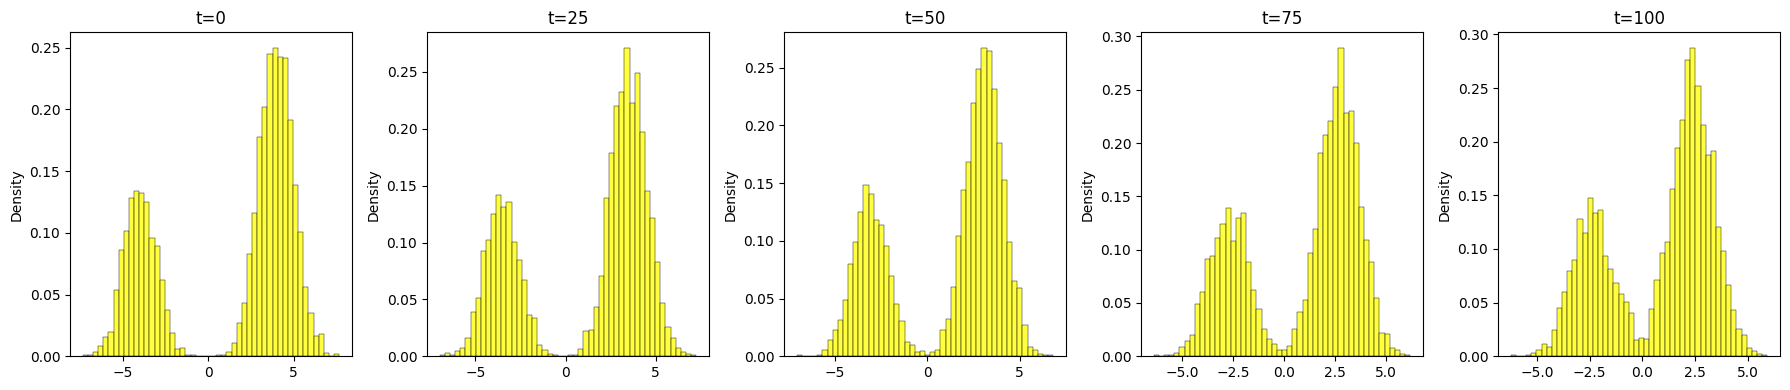

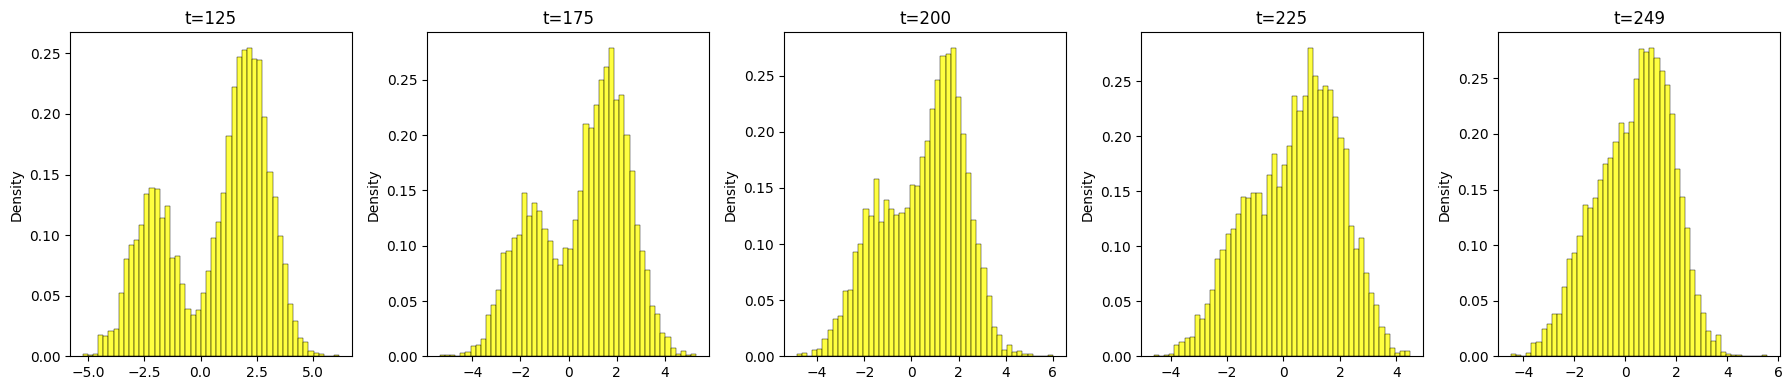

These are forward diffusion visulaisations


In [31]:

# FORWARD DIFFUSION VISUALIZATION


fig, axes = plt.subplots(
    1,
    5,
    figsize=(18,4)
)


indices = [0,25,50,75,100]
steps = indices[:5]

x0 = dataset[:5000]

for ax, t in zip(axes, steps):

    eps = torch.randn_like(x0)

    alpha_bar_t = alpha_bars[t]

    xt = (
        torch.sqrt(alpha_bar_t) * x0
        +
        torch.sqrt(1 - alpha_bar_t) * eps
    )

    sns.histplot(
        xt.numpy(),
        bins=50,
        stat="density",
        ax=ax,
        color="yellow"
    )

    ax.set_title(f"t={t}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    1,
    5,
    figsize=(18,4)
)


indices = [125, 175, 200, 225, 249]
steps = indices[:5]

x0 = dataset[:5000]

for ax, t in zip(axes, steps):

    eps = torch.randn_like(x0)

    alpha_bar_t = alpha_bars[t]

    xt = (
        torch.sqrt(alpha_bar_t) * x0
        +
        torch.sqrt(1 - alpha_bar_t) * eps
    )

    sns.histplot(
        xt.numpy(),
        bins=50,
        stat="density",
        ax=ax,
        color="yellow"
    )

    ax.set_title(f"t={t}")

plt.tight_layout()
plt.show()
print("These are forward diffusion visulaisations")



### GIF for Forward Diffusion Progression

Generating 26 frames for the GIF...
Frames generated. Creating GIF...
GIF saved to forward_diffusion.gif. Displaying...


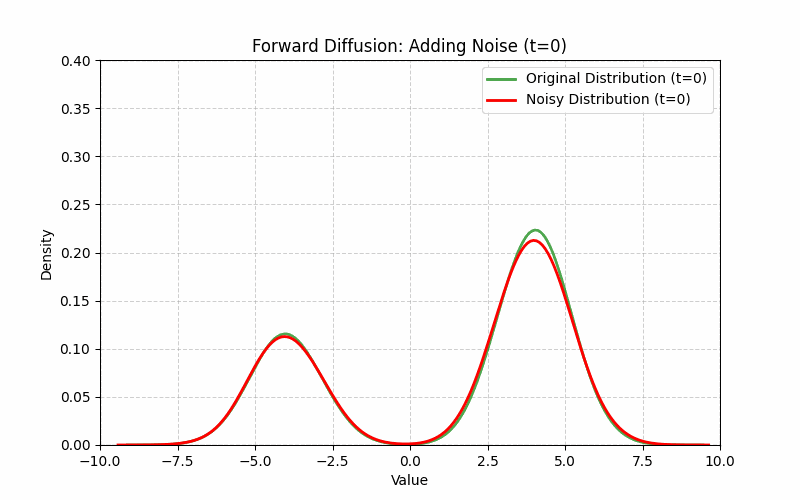

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import imageio.v2 as imageio
import os
from IPython.display import Image, display

# Ensure the 'gifs' directory exists
os.makedirs('gifs', exist_ok=True)

# Select a subset of data for visualization (e.g., 5000 samples)
x0_vis = dataset[:5000]

# List to store filenames of frames
filenames = []

# Define the steps for which to create frames.
# We'll create frames for every 10th step to keep the GIF size reasonable.
# This will generate (250/10) + 1 = 26 frames.
frame_steps = list(range(0, TIME_STEPS, 10)) # From t=0 to t=240 (if TIME_STEPS=250)
if (TIME_STEPS - 1) not in frame_steps:
    frame_steps.append(TIME_STEPS - 1) # Ensure the final step is included

print(f"Generating {len(frame_steps)} frames for the GIF...")

for t in frame_steps:
    # Calculate xt for the current time step
    eps = torch.randn_like(x0_vis)
    alpha_bar_t = alpha_bars[t]
    xt = (
        torch.sqrt(alpha_bar_t) * x0_vis
        +
        torch.sqrt(1 - alpha_bar_t) * eps
    )

    # Create plot
    plt.figure(figsize=(8, 5))
    sns.kdeplot(
        dataset.numpy(),
        label="Original Distribution (t=0)",
        color="g",
        linewidth=2,
        alpha=0.7
    )
    sns.kdeplot(
        xt.numpy(),
        label=f"Noisy Distribution (t={t})",
        color="r",
        linewidth=2
    )
    plt.title(f"Forward Diffusion: Adding Noise (t={t})")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 0.4) # Adjusted y-limit for consistent visualization
    plt.xlim(-10, 10) # Set a fixed x-limit for consistent visualization

    # Save frame
    filename = f"gifs/forward_diffusion_t_{t:03d}.png"
    plt.savefig(filename)
    plt.close() # Close the plot to free memory
    filenames.append(filename)

print("Frames generated. Creating GIF...")

# Create GIF
gif_path = "forward_diffusion.gif"
with imageio.get_writer(gif_path, mode='I', fps=5) as writer: # fps is frames per second
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f"GIF saved to {gif_path}. Displaying...")

# Display GIF in notebook
display(Image(open(gif_path,'rb').read()))

# Optional: Clean up individual frame images and directory
# for filename in filenames:
#     os.remove(filename)
# os.rmdir('gifs')

These plots shows process of adding noise to a input image in forward diffusion step. it was done in total of 250 steps, strating from 0 to 249 (max-range) time steps. The final image resembles a guasian distribution with some discrepencies. However, the purpose of generator is to learn the noises being added so that the reverse diffusion can add those noise in reverse order to get to the target image. we can see the reverse process below.

### Reverse Diffusion Visulaization

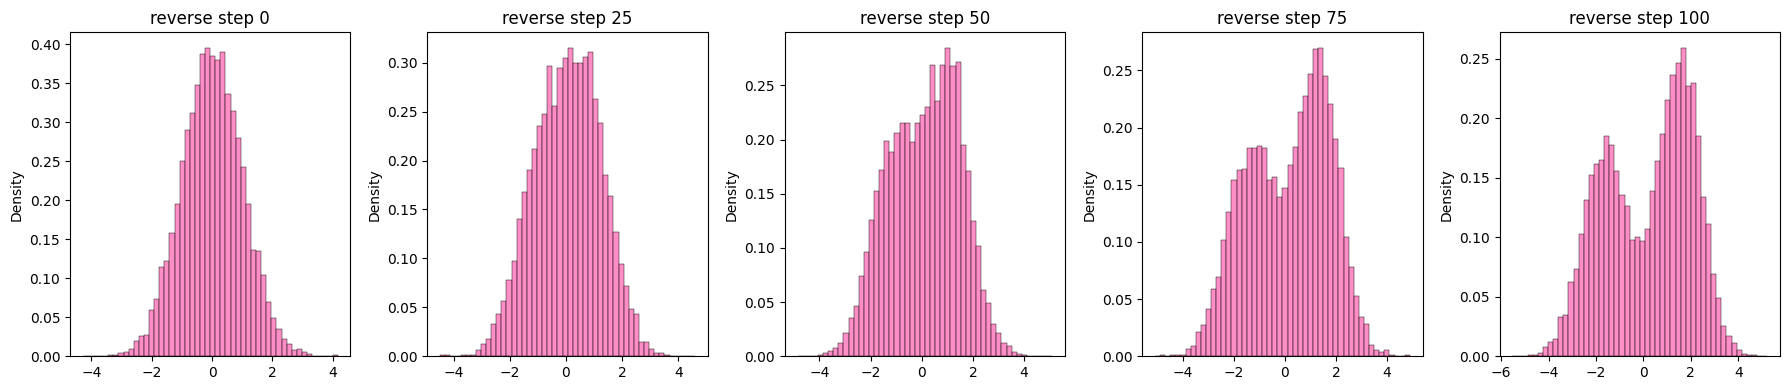

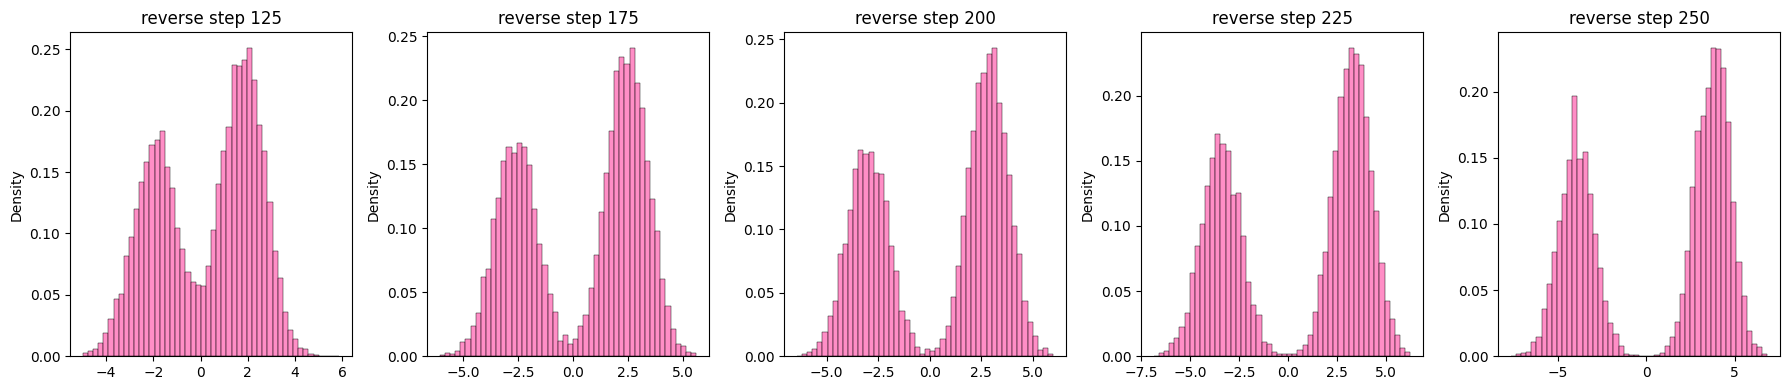

In [28]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(18,4)
)

indices = [0,25,50,75,100]


for ax, idx in zip(axes, indices):

    sns.histplot(
        trajectory[idx].detach().numpy(),
        bins=50,
        stat="density",
        ax=ax,
        color="hotpink"
    )

    ax.set_title(f"reverse step {idx}")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(
    1,
    5,
    figsize=(18,4)
)

indices = [125, 175, 200, 225, 250]
for ax, idx in zip(axes, indices):

    sns.histplot(
        trajectory[idx].detach().numpy(),
        bins=50,
        stat="density",
        ax=ax,
        color="hotpink"
    )

    ax.set_title(f"reverse step {idx}")

plt.tight_layout()
plt.show()

### GIF for Reverse Diffusion Progression

Generating 26 frames for the Reverse Diffusion GIF...
Reverse diffusion frames generated. Creating GIF...
Reverse Diffusion GIF saved to reverse_diffusion.gif. Displaying...


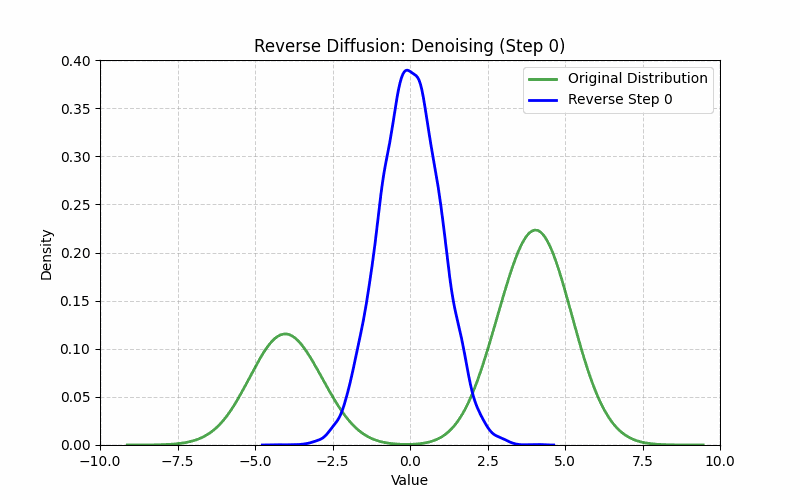

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import imageio.v2 as imageio
import os
from IPython.display import Image, display

# Ensure the 'gifs' directory exists
os.makedirs('gifs', exist_ok=True)

# List to store filenames of frames for reverse diffusion
filenames_rev = []

# Define the indices from the trajectory for which to create frames.
# trajectory[0] is x_T (pure noise), trajectory[TIME_STEPS] is x_0 (denoised sample).
# We'll create frames for every 10th index in the trajectory.
frame_indices_rev = list(range(0, TIME_STEPS + 1, 10))

print(f"Generating {len(frame_indices_rev)} frames for the Reverse Diffusion GIF...")

for i, idx in enumerate(frame_indices_rev):
    # Get the distribution at the current reverse step from the trajectory
    # trajectory[idx] corresponds to the state after 'idx' denoising steps (or x_{T-idx})
    current_x = trajectory[idx].detach().numpy()

    # Create plot
    plt.figure(figsize=(8, 5))
    sns.kdeplot(
        dataset.numpy(),
        label="Original Distribution",
        color="g",
        linewidth=2,
        alpha=0.7
    )
    sns.kdeplot(
        current_x,
        label=f"Reverse Step {idx}",
        color="b",
        linewidth=2
    )
    plt.title(f"Reverse Diffusion: Denoising (Step {idx})")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 0.4) # Consistent y-limit
    plt.xlim(-10, 10) # Consistent x-limit

    # Save frame
    filename = f"gifs/reverse_diffusion_step_{idx:03d}.png"
    plt.savefig(filename)
    plt.close() # Close the plot to free memory
    filenames_rev.append(filename)

print("Reverse diffusion frames generated. Creating GIF...")

# Create GIF
gif_path_rev = "reverse_diffusion.gif"
with imageio.get_writer(gif_path_rev, mode='I', fps=5) as writer:
    for filename in filenames_rev:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f"Reverse Diffusion GIF saved to {gif_path_rev}. Displaying...")

# Display GIF in notebook
display(Image(open(gif_path_rev,'rb').read()))

# Optional: Clean up individual frame images and directory
# for filename in filenames_rev:
#     os.remove(filename)
# os.rmdir('gifs')

Starting from noised Gussian Distribution, we are going back to Target image generation. At reverse step 250, we can see the image generated resembles the target image with some error, that will be quantified later in the notebook.

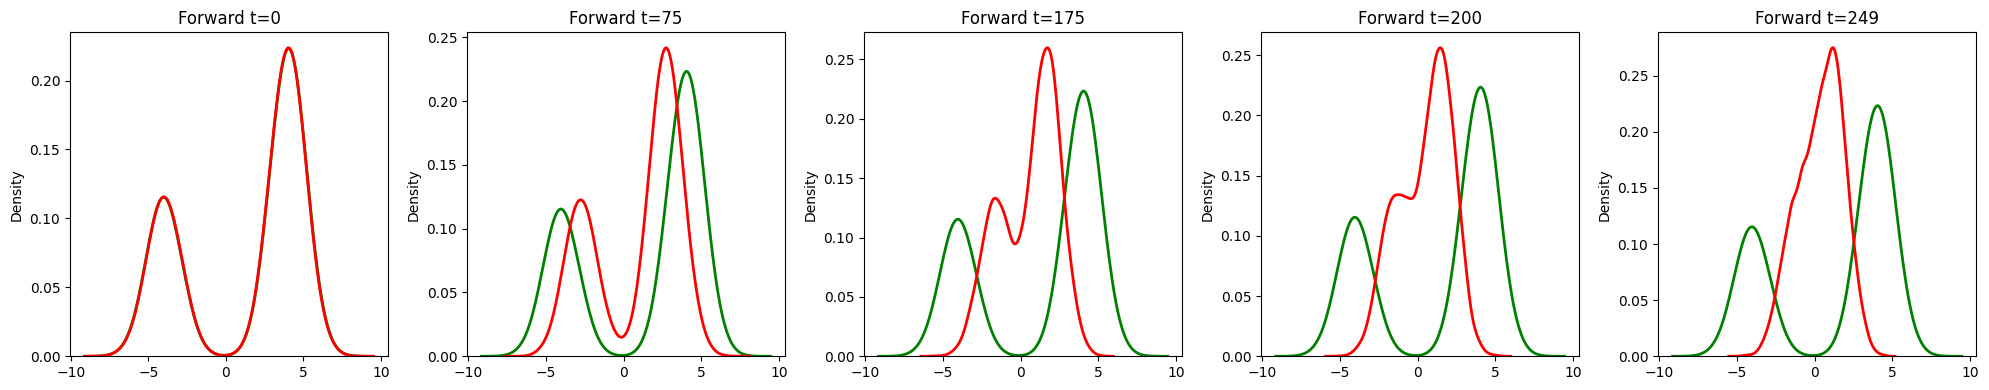

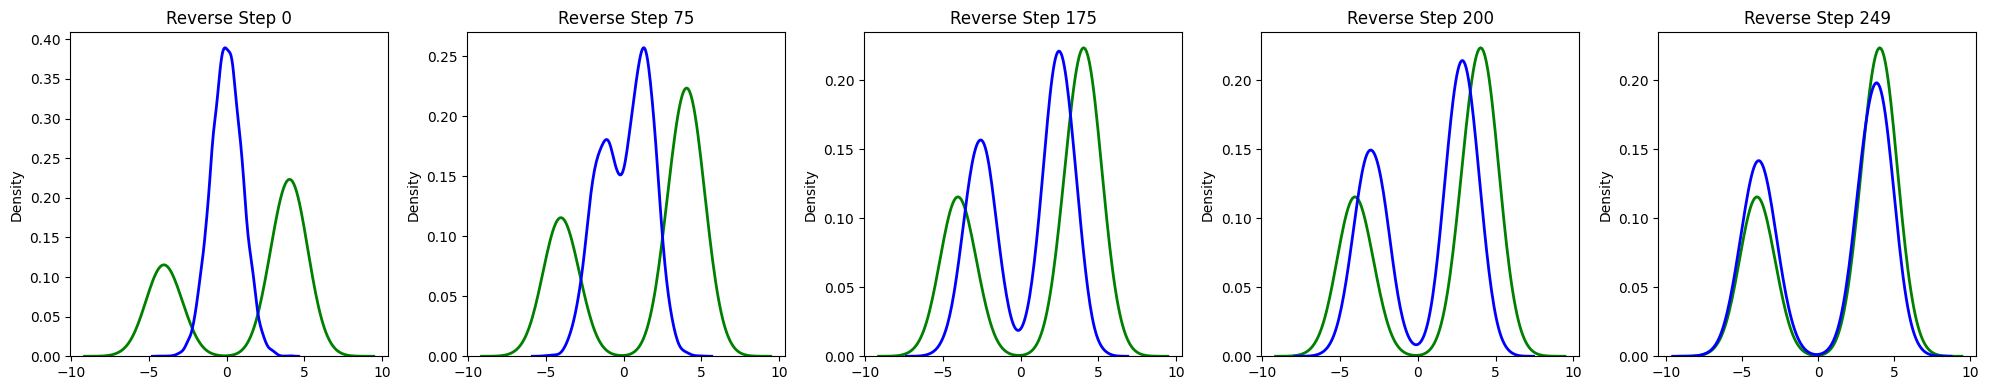

In [42]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(20,4)
)


indices = [0,75, 175, 200, 249]

for ax, t in zip(axes, indices):

    eps = torch.randn_like(dataset)

    alpha_bar_t = alpha_bars[t]

    xt = (
        torch.sqrt(alpha_bar_t) * dataset
        +
        torch.sqrt(1 - alpha_bar_t) * eps
    )

    sns.kdeplot(
        dataset.numpy(),
        ax=ax,
        label="Original",
        linewidth=2,
        color="g"
    )

    sns.kdeplot(
        xt.numpy(),
        ax=ax,
        label="Noisy",
        linewidth=2,
        color="r"
    )

    ax.set_title(f"Forward t={t}")

plt.tight_layout()
plt.show()


# REVERSE DIFFUSION VISUALIZATION


fig, axes = plt.subplots(
    1,
    5,
    figsize=(20,4)
)

# Assuming 'trajectory' is available from a previous cell's execution
# If not, you might need to run the sampling step again.
indices_rev = [0,75, 175, 200, 249] # Example reverse steps

for ax, idx in zip(axes, indices_rev):
    sns.kdeplot(
        dataset.numpy(),
        ax=ax,
        label="Original",
        linewidth=2,
        color="g"
    )

    sns.kdeplot(
        trajectory[idx].detach().numpy(),
        ax=ax,
        label="Reverse Step",
        linewidth=2,
        color="b"
    )

    ax.set_title(f"Reverse Step {idx}")

plt.tight_layout()
plt.show()


For visual comparison, of how the input image was noised to get to t=249 in forward diffusion and how it went back. We can see the reverse steps are almost similar to noise steps for comparable time steps. Time 0 of forward corresponds to reverse step 249 in our settings/notations. Similary, Forward t=200 can be compared with Reverse setp 75 and so on.


### Mean Squared Error (MSE) between Target/True and Sample/generated distributions:

It first computes the element-wise difference between the two PDFs, then squares these differences, and finally takes the average of all squared differences. This mse value quantifies the average squared discrepancy between the two distributions. A lower MSE indicates a closer match between the generated and true distributions.

Mean Squared Error between target and sampled distributions (KDEs): 0.000272


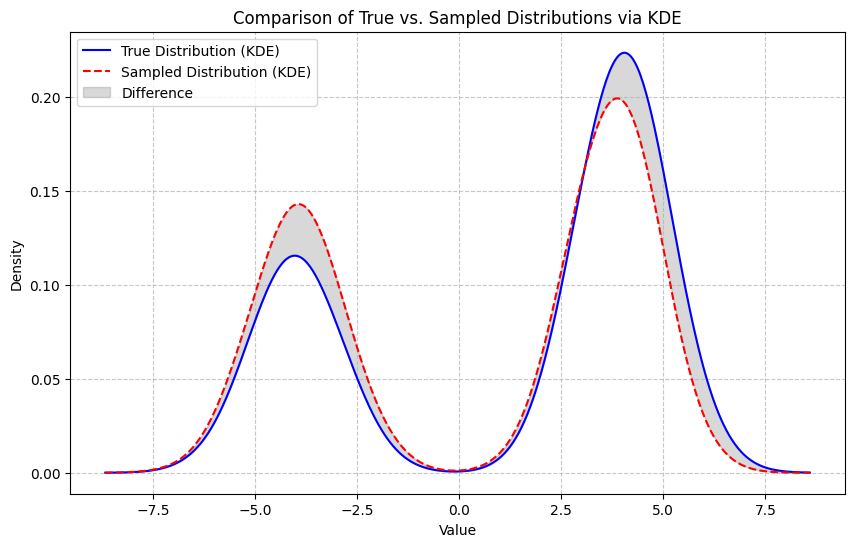

In [32]:
from scipy.stats import gaussian_kde

# Define a common range for evaluation
min_val = min(dataset.min(), samples.min())
max_val = max(dataset.max(), samples.max())
x_eval = np.linspace(min_val - 1, max_val + 1, 500) # Extend slightly beyond min/max

# Get KDE for the true dataset
kde_dataset = gaussian_kde(dataset.numpy().flatten())
pdf_dataset = kde_dataset(x_eval)

# Get KDE for the generated samples
kde_samples = gaussian_kde(samples.flatten())
pdf_samples = kde_samples(x_eval)

# Calculate Mean Squared Error between the PDFs
mse = np.mean((pdf_dataset - pdf_samples)**2)

print(f"Mean Squared Error between target and sampled distributions (KDEs): {mse:.6f}")

# Optionally, visualize the KDEs for verification
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(x_eval, pdf_dataset, label='True Distribution (KDE)', color='blue')
ax.plot(x_eval, pdf_samples, label='Sampled Distribution (KDE)', color='red', linestyle='--')
ax.fill_between(x_eval, pdf_dataset, pdf_samples, color='grey', alpha=0.3, label='Difference')
ax.set_title('Comparison of True vs. Sampled Distributions via KDE')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

MSE is quite low, which is a good sign. It means regenerated image resembles the target image to a great extent, with MSE of only 0.0272%.

**KL Divergence** (also known as relative entropy) quantifies the information lost when one probability distribution is used to approximate another. It's a measure of how one probability distribution P diverges from a second, expected probability distribution Q.

KL(P || Q) is generally not equal to KL(Q || P). In our case, KL(True || Generated) tells us how much information is lost when using the generated distribution to approximate the true distribution.

It's always non-negative, and is 0 if and only if the distributions P and Q are identical.

KL divergence is very sensitive to regions where the approximating distribution (Q) assigns a low probability, but the true distribution (P) assigns a high probability. This means it heavily penalizes the generated distribution for missing parts of the true distribution.

KL Divergence is often preferred in generative modeling (like diffusion models) because the goal is to generate samples that belong to the same distribution as the real data. It focuses on how well the generated distribution covers and matches the true distribution's information content. A low KL divergence indicates that the generated distribution is a good approximation of the true distribution in an information-theoretic sense.

In [41]:
from scipy.special import rel_entr

# Ensure PDFs are non-zero to avoid issues with log
epsilon = 1e-10
pdf_dataset_safe = pdf_dataset + epsilon
pdf_samples_safe = pdf_samples + epsilon

# Calculate KL divergence
# Using scipy's rel_entr which computes P * log(P/Q)
# Ensure the step size is a float to avoid type conflicts with Tensor
step_size = float(x_eval[1] - x_eval[0])
kl_divergence = np.sum(rel_entr(pdf_dataset_safe, pdf_samples_safe) * step_size)

print(f"Kullback-Leibler Divergence (KL(True || Generated)): {kl_divergence:.6f}")

Kullback-Leibler Divergence (KL(True || Generated)): 0.030607


The Kullback-Leibler (KL) Divergence between the true and generated distributions is 0.030607. This value indicates a good match between the distributions, as a lower KL divergence signifies greater similarity. This quantitative result aligns well with the visual comparison we observed in the KDE plot, where the generated distribution closely follows the true distribution.

### Training and  Validation Loss Curves

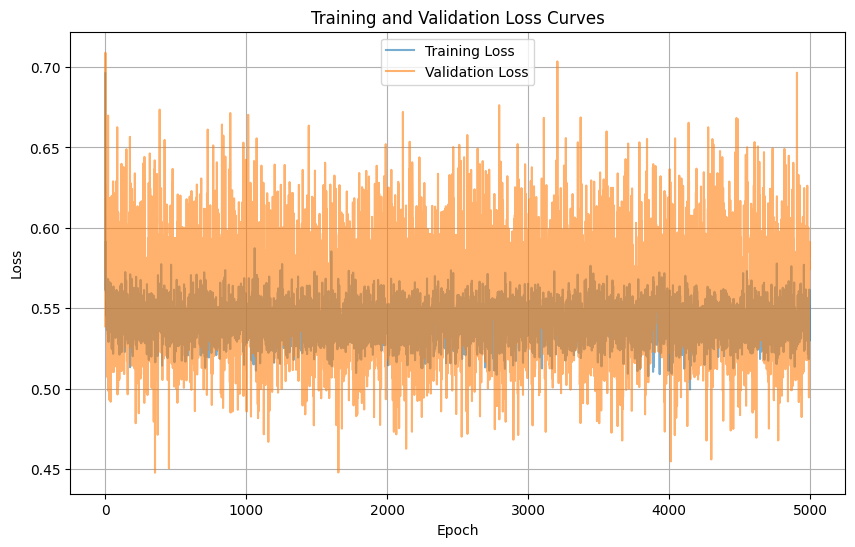

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', alpha=0.6)
plt.plot(val_losses, label='Validation Loss', alpha=0.6)
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Training and Validation Loss Curves

Looking at the generated plot, we can make the following observations about our model's performance:

*  Over the 5000 epochs, neither the training loss nor the validation loss shows a significant decreasing trend. They both hover around a similar range, indicating that the model is not effectively learning or improving its performance over time.
*   Both losses remain relatively high and exhibit considerable fluctuation. This suggests instability in the training process and a potential lack of convergence.
* Since neither curve is consistently decreasing, and there isn't a significant and growing gap between them, it's hard to definitively say the model is overfitting or underfitting in the classical sense based solely on these curves. However, the high and non-decreasing losses lean more towards a state of **underfitting** or a model that is simply not learning effectively.

**Conclusion**: The current training process does not appear to be leading to a well-converged or well-generalized model. Both training and validation losses are stagnant and high, indicating that the model is struggling to learn the underlying patterns in the data. This might suggest issues with the model architecture, hyperparameters (like learning rate or `BETA`), or the duration of training not being sufficient to break out of this plateau.

**Key Insight & Discrepancy:**

An interesting observation is the discrepancy between the high and fluctuating training/validation losses for the `NoisePredictor` and the very low MSE/KL divergence for the final generated samples. This highlights the robustness of diffusion models: even if the noise prediction at individual steps isn't perfect, the cumulative effect of many denoising steps can still lead to high-quality final samples that closely match the target distribution.

### Explaining the Discrepancy: Low Sample MSE vs. High Training/Validation Loss   - More Detail just for my notes

It might seem contradictory that we observe a relatively low Mean Squared Error (MSE) between the final generated samples and the true distribution, while the training and validation loss curves remain high and flat. Here's why this can happen (in the context of a diffusion model):

1.  **What the Losses Represent (Noise Prediction)**:
    *   The `train_losses` and `val_losses` are measuring the performance of the `NoisePredictor` network (`g`) itself. This network is trained to predict the noise `eps` that was added at a given time step `t` to `x0` to get `xt`.
    *   The loss function (`loss_fn = torch.nn.MSELoss()`) is comparing `pred_eps` (the noise predicted by the model) with the actual `eps` (the noise that was truly sampled and added).
    *   A high and fluctuating loss here means that the `NoisePredictor` is not very good at accurately predicting the noise `eps` at each individual step. It struggles to minimize the MSE between its prediction and the true noise.

2.  **What the Sample MSE Represents (Distribution Matching)**:
    *   The MSE calculated between the `pdf_dataset` and `pdf_samples` (and similarly the KL Divergence) is a metric for how well the *final distribution* of the samples generated by the *entire reverse diffusion process* matches the *true data distribution*.
    *   This metric assesses the quality of the output after iterating through all `TIME_STEPS` of the denoising process.

3.  **The Cumulative Effect in Diffusion Models**:
    *   Diffusion models are very robust. Even if the `NoisePredictor` isn't perfectly accurate at every single step (leading to high training loss), the cumulative effect of many small denoising steps can still lead to a reasonably good final sample distribution.
    *   The `NoisePredictor` doesn't need to be perfect; it just needs to guide the reverse process generally towards the data manifold. A small error in `eps` prediction at one step might be compensated or smoothed out over subsequent steps.

4.  **Magnitude of `eps` vs. Data Scale**:
    *   The noise `eps` might operate on a different scale than the `x` values, or it might be that the model's predictions of `eps` are sufficient for guiding the reverse process, even if the absolute MSE on `eps` prediction seems high.

In summary, the high training/validation loss indicates that our `NoisePredictor` is not performing optimally on its direct task of predicting noise, potentially suggesting issues with the model's capacity, learning rate, or training duration. However, the low MSE on the *final samples* indicates that, despite these individual step-by-step inaccuracies, the *overall reverse diffusion process* is still effective enough to generate samples that closely resemble the target data distribution. It's a testament to the robustness of the diffusion process itself.